# 📊 Phase 6 — Visualisation du Dashboard

**Projet : African Media Intelligence AI**  
**Auteur : Esmel Amari (Phil)**  
**Description :** Ce notebook génère un dashboard visuel complet en Python (matplotlib + seaborn + wordcloud) reproduisant les visuels clés d'un tableau de bord Power BI.

---

### Visuels générés
| # | Visuel | Données source |
|---|---|---|
| 1 | KPI Cards — Indicateurs clés | Articles + Entités + Réputation |
| 2 | Donut — Distribution des sentiments | Articles |
| 3 | Barres empilées — Sentiment par source | Articles |
| 4 | Courbes — Évolution temporelle | Sentiment_Evol |
| 5 | Barres horizontales — Top entités citées | Entités |
| 6 | Barres — RepScore par entité | Réputation |
| 7 | Barres horizontales — Distribution des topics | Articles |
| 8 | Nuage de mots — Mots-clés tendances | Keywords |


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from wordcloud import WordCloud
from pathlib import Path
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# ── Chemins ────────────────────────────────────────────────────────
BASE_DIR    = Path('..').resolve()
PROC_DIR    = BASE_DIR / 'data' / 'processed'
EXPORTS_DIR = BASE_DIR / 'exports'
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Palette couleurs thème africain ───────────────────────────────
PALETTE = {
    'positif'    : '#27AE60',
    'neutre'     : '#F39C12',
    'negatif'    : '#E74C3C',
    'bg'         : '#F8F9FA',
    'dark'       : '#2C3E50',
    'accent'     : '#E67E22',
    'blue'       : '#2980B9',
    'purple'     : '#8E44AD',
    'teal'       : '#16A085',
    'red'        : '#C0392B',
    'header_bg'  : '#2C3E50',
    'card_bg'    : '#FFFFFF',
}

# ── Style global matplotlib ────────────────────────────────────────
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 10,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'figure.facecolor'  : PALETTE['bg'],
    'axes.facecolor'    : '#FFFFFF',
})

print('✅ Configuration prête')

✅ Configuration prête


## 1. Chargement des Données

In [5]:
def load_latest(directory: Path, pattern: str) -> pd.DataFrame | None:
    files = sorted(directory.glob(pattern), reverse=True)
    return pd.read_csv(files[0], encoding='utf-8-sig') if files else None

# Charger tous les datasets
df_art = load_latest(PROC_DIR, 'articles_ner_*.csv')

if df_art is None:
    df_art = load_latest(PROC_DIR, 'articles_*.csv')
df_ent = load_latest(PROC_DIR, 'entities_flat_*.csv')
df_rep = load_latest(PROC_DIR, 'reputation_scores_*.csv')
df_evo = load_latest(PROC_DIR, 'sentiment_evolution_*.csv')
df_top = load_latest(PROC_DIR, 'topics_summary.csv')
df_kw  = load_latest(PROC_DIR, 'keywords_trending.csv')

# Renommage flexible selon conventions CSV générées
if df_rep is not None:
    df_rep.columns = [
        c.replace('entite','Entité').replace('type_entite','Type')
         .replace('nb_mentions','Nb Mentions').replace('rep_score','RepScore')
         .replace('statut_reputation','Statut Réputation')
         .replace('nb_positif','Nb Positif').replace('nb_negatif','Nb Négatif')
         .replace('nb_neutre','Nb Neutre')
        for c in df_rep.columns
    ]

# Nommer la colonne sentiment si besoin
if df_art is not None:
    col_sent = next((c for c in df_art.columns
                     if 'sentiment' in c.lower()), None)
    if col_sent and col_sent != 'Sentiment':
        df_art.rename(columns={col_sent: 'Sentiment'}, inplace=True)
    col_src = next((c for c in df_art.columns
                    if 'source' in c.lower()), None)
    if col_src and col_src != 'Source':
        df_art.rename(columns={col_src: 'Source'}, inplace=True)
    col_top = next((c for c in df_art.columns
                    if 'topic_label' in c.lower() or c == 'Topic'), None)
    if col_top and col_top != 'Topic':
        df_art.rename(columns={col_top: 'Topic'}, inplace=True)

print('✅ Données chargées :')
for name, df in [('Articles', df_art),('Entités', df_ent),('Réputation', df_rep),
                  ('Évolution', df_evo),('Topics', df_top),('Keywords', df_kw)]:
    status = f'{len(df)} lignes' if df is not None else '⚠️ manquant'
    print(f'  {name:<12} → {status}')

✅ Données chargées :
  Articles     → 121 lignes
  Entités      → 532 lignes
  Réputation   → 58 lignes
  Évolution    → 23 lignes
  Topics       → 8 lignes
  Keywords     → 100 lignes


## 2. Fonctions Utilitaires de Visualisation

In [6]:
def add_title_bar(fig, title: str, subtitle: str = ''):
    """Ajoute une barre de titre en haut de la figure."""
    fig.text(0.5, 0.99, title,
             ha='center', va='top', fontsize=16, fontweight='bold',
             color='white',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['dark'],
                       edgecolor='none', alpha=1))
    if subtitle:
        fig.text(0.5, 0.963, subtitle,
                 ha='center', va='top', fontsize=9,
                 color=PALETTE['dark'], style='italic')


def kpi_card(ax, value, label, color, icon=''):
    """Dessine une carte KPI dans un axe matplotlib."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    # Fond coloré
    rect = FancyBboxPatch((0.02, 0.05), 0.96, 0.90,
                           boxstyle='round,pad=0.02',
                           facecolor=color, edgecolor='white',
                           linewidth=2, zorder=1)
    ax.add_patch(rect)
    # Icône
    ax.text(0.5, 0.78, icon, ha='center', va='center',
            fontsize=22, zorder=2)
    # Valeur
    ax.text(0.5, 0.50, str(value), ha='center', va='center',
            fontsize=20, fontweight='bold', color='white', zorder=2)
    # Label
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold',
            wrap=True, zorder=2)


def bar_value_labels(ax, bars, fmt='{:.0f}', offset=0.5, color='#2C3E50', fontsize=9):
    """Ajoute les valeurs au-dessus des barres verticales."""
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + offset, fmt.format(h),
                    ha='center', va='bottom',
                    fontsize=fontsize, color=color, fontweight='bold')


def hbar_value_labels(ax, bars, fmt='{:.0f}', offset=0.2, color='#2C3E50', fontsize=9):
    """Ajoute les valeurs à droite des barres horizontales."""
    for bar in bars:
        w = bar.get_width()
        if w > 0:
            ax.text(w + offset, bar.get_y() + bar.get_height() / 2,
                    fmt.format(w),
                    ha='left', va='center',
                    fontsize=fontsize, color=color, fontweight='bold')


print('✅ Fonctions utilitaires définies')

✅ Fonctions utilitaires définies


## 3. Dashboard Principal — Toutes Visualisations


✅ Dashboard sauvegardé : C:\Users\E682\Desktop\exports\dashboard_african_media_20260512_2049.png


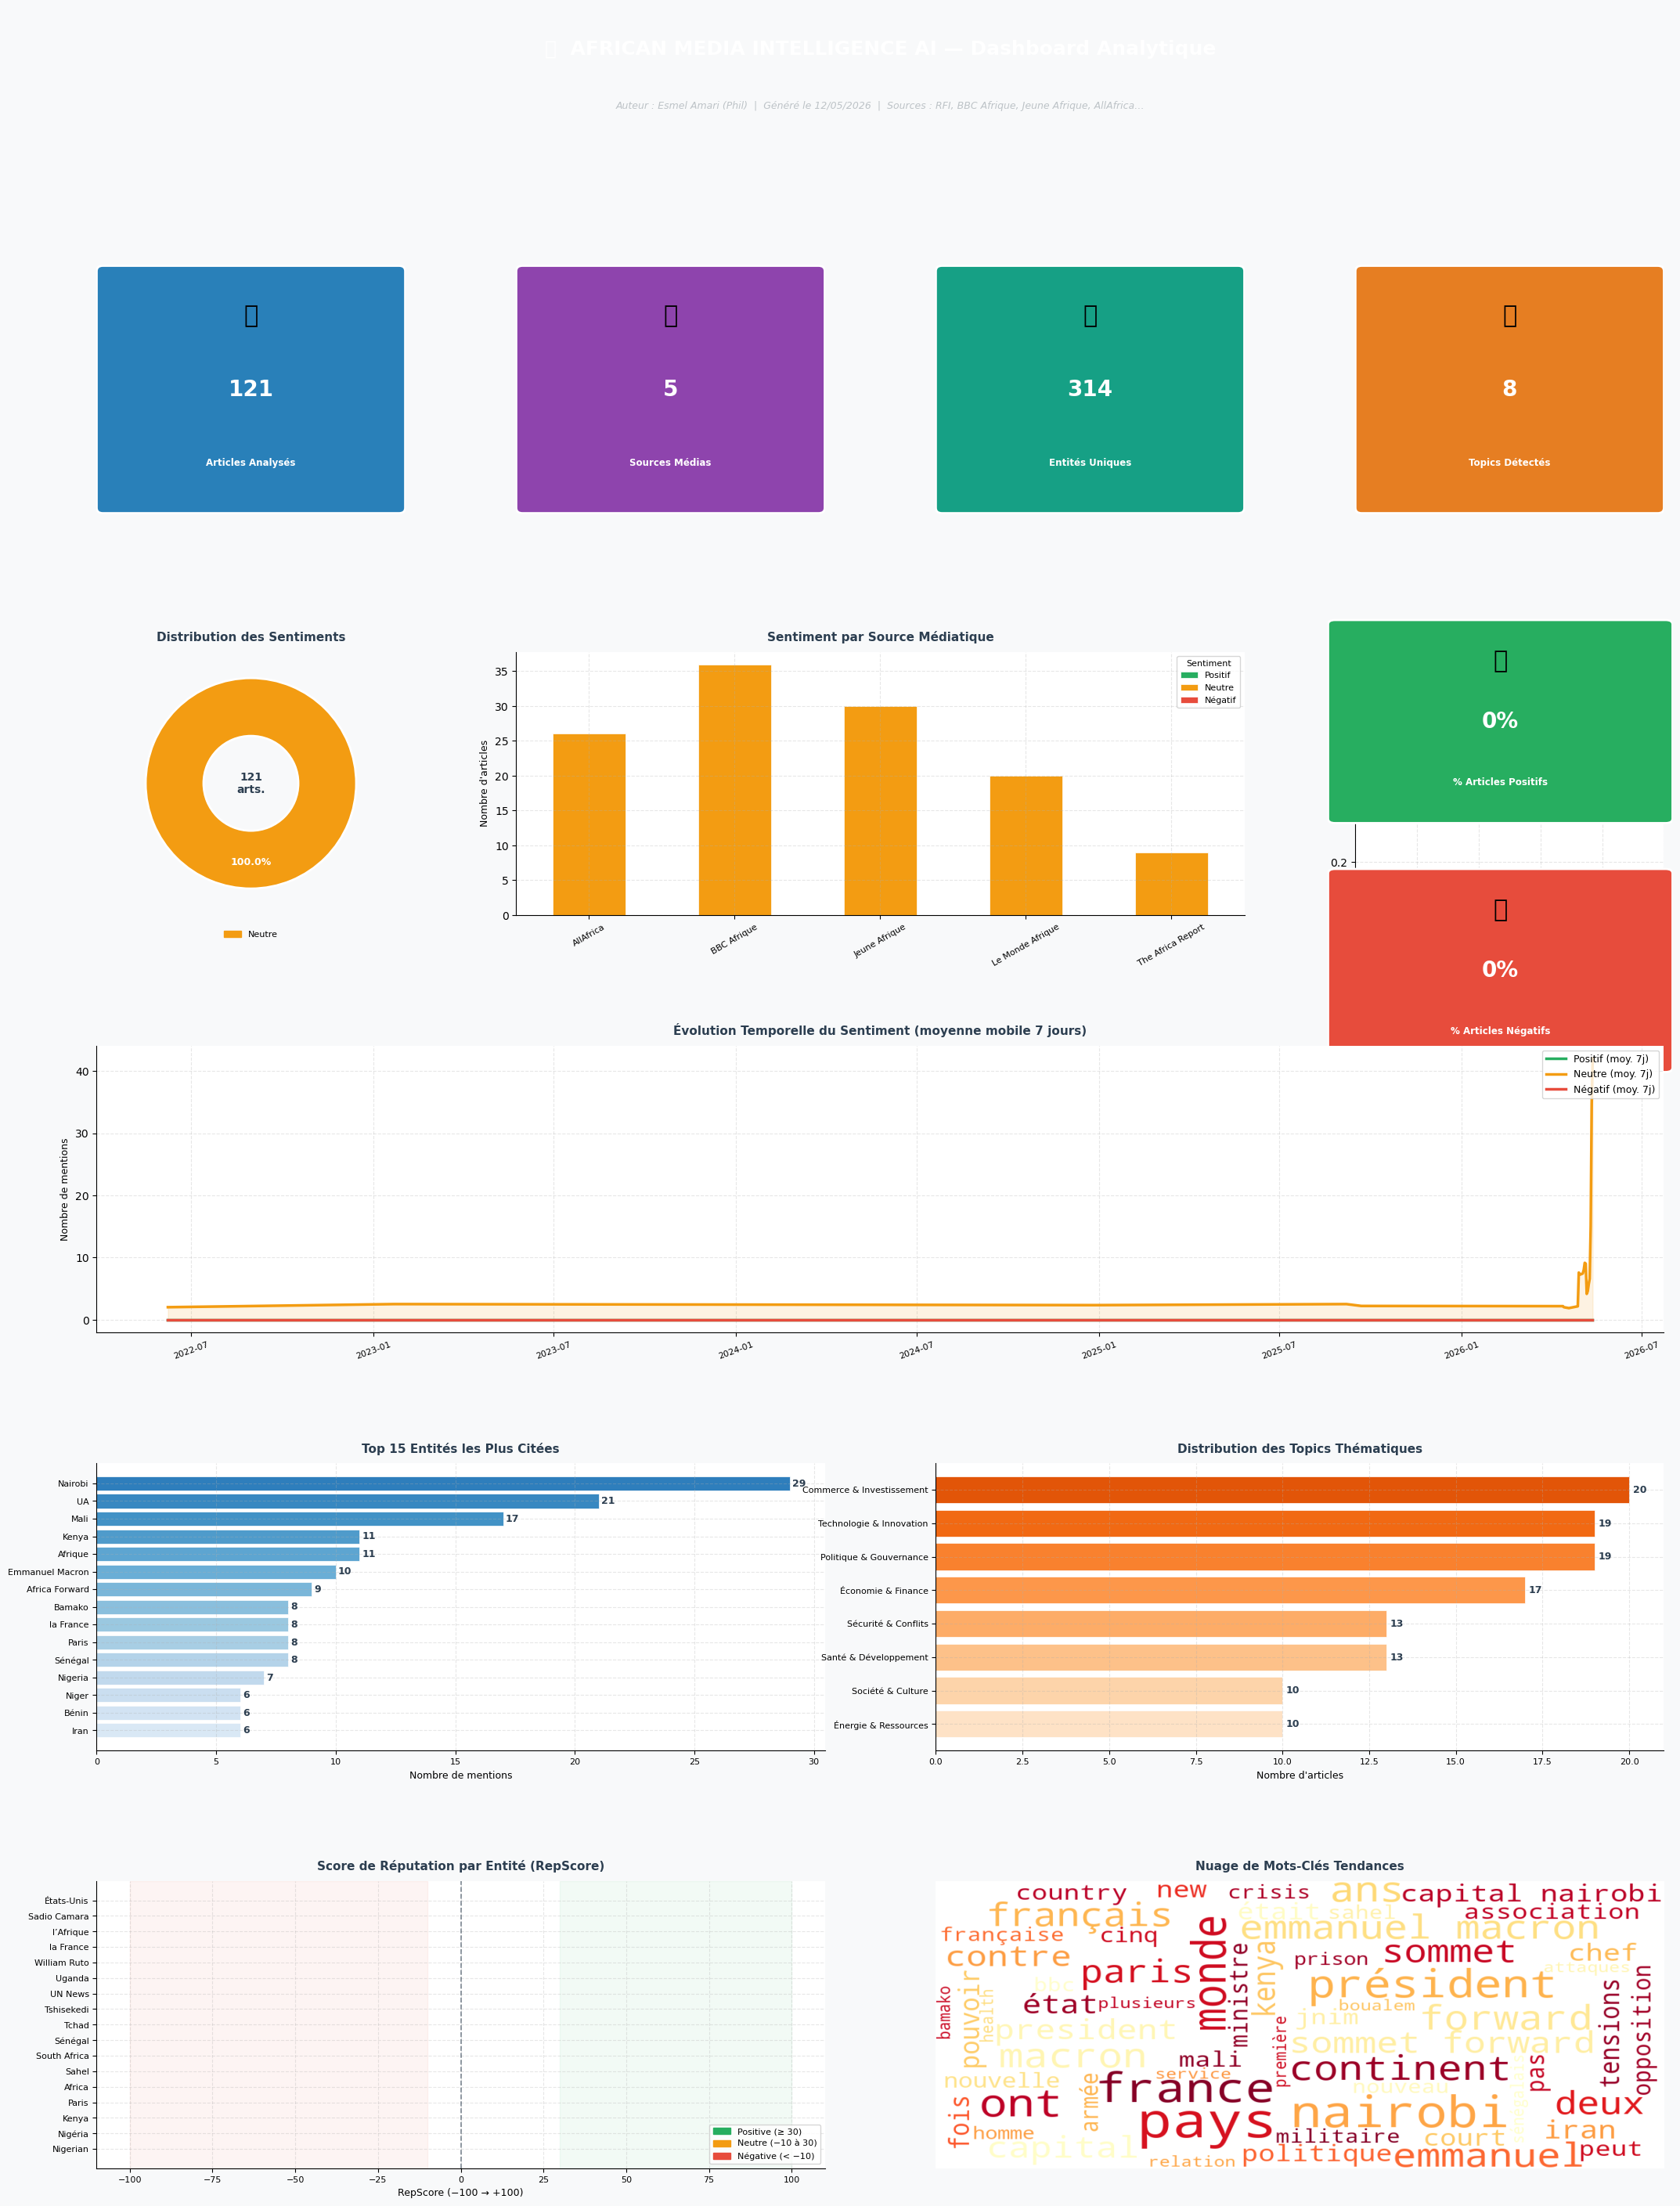

In [7]:
fig = plt.figure(figsize=(22, 30), facecolor=PALETTE['bg'])
fig.subplots_adjust(left=0.05, right=0.96, top=0.95, bottom=0.03,
                    hspace=0.50, wspace=0.35)

# ── Grid layout ────────────────────────────────────────────────────
gs = gridspec.GridSpec(
    nrows=6, ncols=4,
    figure=fig,
    height_ratios=[0.50, 1.10, 1.10, 1.20, 1.20, 1.20],
    hspace=0.52, wspace=0.36
)

# ══════════════════════════════════════════════════════════
# LIGNE 0 — Titre principal
# ══════════════════════════════════════════════════════════
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(PALETTE['dark'])
ax_title.axis('off')
ax_title.text(0.5, 0.65,
              '🌍  AFRICAN MEDIA INTELLIGENCE AI — Dashboard Analytique',
              ha='center', va='center',
              fontsize=18, fontweight='bold', color='white')
date_str = datetime.now().strftime('%d/%m/%Y')
ax_title.text(0.5, 0.18,
              f'Auteur : Esmel Amari (Phil)  |  Généré le {date_str}  |  Sources : RFI, BBC Afrique, Jeune Afrique, AllAfrica…',
              ha='center', va='center',
              fontsize=9, color='#BDC3C7', style='italic')
for spine in ax_title.spines.values():
    spine.set_visible(False)


# ══════════════════════════════════════════════════════════
# LIGNE 1 — KPI Cards
# ══════════════════════════════════════════════════════════

# Calcul des KPIs
n_articles  = len(df_art) if df_art is not None else 0
n_sources   = df_art['Source'].nunique() if df_art is not None and 'Source' in df_art.columns else 0
n_entites   = df_ent['entite'].nunique() if df_ent is not None and 'entite' in df_ent.columns else \
              (df_rep['Entité'].nunique() if df_rep is not None and 'Entité' in df_rep.columns else 0)
n_topics    = df_top['label'].nunique() if df_top is not None and 'label' in df_top.columns else \
              (df_art['Topic'].nunique() if df_art is not None and 'Topic' in df_art.columns else 0)

if df_art is not None and 'Sentiment' in df_art.columns:
    sent_dist = df_art['Sentiment'].value_counts(normalize=True) * 100
    pct_pos   = round(sent_dist.get('Positif', 0), 1)
    pct_neg   = round(sent_dist.get('Négatif', 0), 1)
else:
    pct_pos, pct_neg = 0, 0

kpis = [
    (n_articles,       'Articles Analysés',   PALETTE['blue'],   '📰'),
    (n_sources,        'Sources Médias',       PALETTE['purple'], '📡'),
    (n_entites,        'Entités Uniques',      PALETTE['teal'],   '🏢'),
    (n_topics,         'Topics Détectés',      PALETTE['accent'], '📌'),
    (f'{pct_pos}%',    '% Articles Positifs',  PALETTE['positif'],'🟢'),
    (f'{pct_neg}%',    '% Articles Négatifs',  PALETTE['negatif'],'🔴'),
]

# Afficher les 4 KPIs sur la ligne 1 (2 colonnes chacun)
for i, (val, label, color, icon) in enumerate(kpis[:4]):
    ax_kpi = fig.add_subplot(gs[1, i])
    kpi_card(ax_kpi, val, label, color, icon)


# ══════════════════════════════════════════════════════════
# LIGNE 2 — Donut Sentiment | Sentiment par Source | KPI Pos/Nég
# ══════════════════════════════════════════════════════════

# ── Donut : Distribution des sentiments ──
ax_donut = fig.add_subplot(gs[2, 0])
ax_donut.set_facecolor('#FFFFFF')

if df_art is not None and 'Sentiment' in df_art.columns:
    sent_counts = df_art['Sentiment'].value_counts()
    labels_s    = sent_counts.index.tolist()
    sizes_s     = sent_counts.values.tolist()
    colors_s    = [PALETTE.get(s.lower().replace('é','e'), PALETTE['neutre']) for s in labels_s]
    # Mapper manuellement
    color_map_s = {'Positif': PALETTE['positif'], 'Neutre': PALETTE['neutre'],
                   'Négatif': PALETTE['negatif']}
    colors_s    = [color_map_s.get(l, '#95A5A6') for l in labels_s]

    wedges, texts, autotexts = ax_donut.pie(
        sizes_s, labels=None, colors=colors_s,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
        pctdistance=0.75
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')

    # Centre
    ax_donut.text(0, 0, f'{sum(sizes_s)}\narts.',
                  ha='center', va='center', fontsize=10, fontweight='bold',
                  color=PALETTE['dark'])

    # Légende
    legend_patches = [mpatches.Patch(color=c, label=l)
                      for c, l in zip(colors_s, labels_s)]
    ax_donut.legend(handles=legend_patches, loc='lower center',
                    bbox_to_anchor=(0.5, -0.12), ncol=3,
                    fontsize=8, frameon=False)

ax_donut.set_title('Distribution des Sentiments', fontsize=11,
                    fontweight='bold', color=PALETTE['dark'], pad=10)


# ── Barres : Sentiment par source ──
ax_src = fig.add_subplot(gs[2, 1:3])

if df_art is not None and 'Sentiment' in df_art.columns and 'Source' in df_art.columns:
    pivot_src = (
        df_art.groupby(['Source', 'Sentiment'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=['Positif','Neutre','Négatif'], fill_value=0)
    )
    pivot_src.plot(
        kind='bar', stacked=True, ax=ax_src,
        color=[PALETTE['positif'], PALETTE['neutre'], PALETTE['negatif']],
        edgecolor='white', linewidth=0.5
    )
    ax_src.set_xlabel('')
    ax_src.set_ylabel('Nombre d\'articles', fontsize=9)
    ax_src.tick_params(axis='x', rotation=30, labelsize=8)
    ax_src.legend(title='Sentiment', fontsize=8, title_fontsize=8,
                  loc='upper right', frameon=True)
    ax_src.spines['left'].set_visible(True)

ax_src.set_title('Sentiment par Source Médiatique', fontsize=11,
                  fontweight='bold', color=PALETTE['dark'], pad=10)


# ── KPI cards pos/neg ──
for i, (val, label, color, icon) in enumerate(kpis[4:6]):
    ax_k = fig.add_subplot(gs[2, 3] if i == 0 else gs[2, 3])
    break
# Subdiviser la dernière colonne verticalement manuellement
ax_kp = fig.add_axes([0.765, 0.600, 0.200, 0.092])
ax_kn = fig.add_axes([0.765, 0.494, 0.200, 0.092])
kpi_card(ax_kp, f'{pct_pos}%', '% Articles Positifs',  PALETTE['positif'], '🟢')
kpi_card(ax_kn, f'{pct_neg}%', '% Articles Négatifs',  PALETTE['negatif'], '🔴')


# ══════════════════════════════════════════════════════════
# LIGNE 3 — Évolution temporelle du sentiment
# ══════════════════════════════════════════════════════════
ax_evo = fig.add_subplot(gs[3, :])

if df_evo is not None:
    # Nommer la colonne date
    date_col = next((c for c in df_evo.columns if 'date' in c.lower()), df_evo.columns[0])
    df_evo.rename(columns={date_col: 'Date'}, inplace=True)
    df_evo['Date'] = pd.to_datetime(df_evo['Date'], errors='coerce')
    df_plot = df_evo.sort_values('Date').set_index('Date')

    # Fenêtre glissante 7 jours pour lisser
    df_smooth = df_plot.rolling(window=7, min_periods=1).mean()

    for col, color, label in [
        ('Positif', PALETTE['positif'], 'Positif (moy. 7j)'),
        ('Neutre',  PALETTE['neutre'],  'Neutre (moy. 7j)'),
        ('Négatif', PALETTE['negatif'], 'Négatif (moy. 7j)'),
    ]:
        if col in df_smooth.columns:
            ax_evo.plot(df_smooth.index, df_smooth[col],
                        color=color, linewidth=2.5, label=label, zorder=3)
            ax_evo.fill_between(df_smooth.index, df_smooth[col],
                                alpha=0.12, color=color, zorder=2)

    ax_evo.set_ylabel('Nombre de mentions', fontsize=9)
    ax_evo.set_xlabel('')
    ax_evo.legend(fontsize=9, loc='upper right', frameon=True)
    ax_evo.tick_params(axis='x', rotation=20, labelsize=8)
    ax_evo.set_facecolor('#FFFFFF')

ax_evo.set_title('Évolution Temporelle du Sentiment (moyenne mobile 7 jours)',
                  fontsize=11, fontweight='bold', color=PALETTE['dark'], pad=10)


# ══════════════════════════════════════════════════════════
# LIGNE 4 — Top entités | Topics
# ══════════════════════════════════════════════════════════

# ── Top 15 entités citées (barres horizontales) ──
ax_ent = fig.add_subplot(gs[4, :2])

if df_ent is not None:
    ent_col = next((c for c in df_ent.columns if c in ['entite','Entité']), None)
    if ent_col:
        top_ent = df_ent[ent_col].value_counts().head(15)
        # Gradient de couleurs
        colors_ent = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(top_ent)))
        bars_ent = ax_ent.barh(
            top_ent.index[::-1], top_ent.values[::-1],
            color=colors_ent[::-1], edgecolor='white', linewidth=0.5
        )
        hbar_value_labels(ax_ent, bars_ent, offset=0.1)
        ax_ent.set_xlabel('Nombre de mentions', fontsize=9)
        ax_ent.tick_params(axis='y', labelsize=8)
        ax_ent.tick_params(axis='x', labelsize=8)
        ax_ent.set_facecolor('#FFFFFF')

ax_ent.set_title('Top 15 Entités les Plus Citées', fontsize=11,
                  fontweight='bold', color=PALETTE['dark'], pad=10)


# ── Distribution des Topics ──
ax_top = fig.add_subplot(gs[4, 2:])

if df_art is not None and 'Topic' in df_art.columns:
    topic_counts = df_art['Topic'].value_counts()
    colors_top = plt.cm.Oranges_r(np.linspace(0.3, 0.85, len(topic_counts)))
    bars_top = ax_top.barh(
        topic_counts.index[::-1], topic_counts.values[::-1],
        color=colors_top[::-1], edgecolor='white', linewidth=0.5
    )
    hbar_value_labels(ax_top, bars_top, offset=0.1)
    ax_top.set_xlabel('Nombre d\'articles', fontsize=9)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_top.tick_params(axis='x', labelsize=8)
    ax_top.set_facecolor('#FFFFFF')
elif df_top is not None:
    topic_counts = df_top.set_index('label')['nb_articles'].sort_values()
    ax_top.barh(topic_counts.index, topic_counts.values,
                color=PALETTE['accent'], edgecolor='white')
    ax_top.tick_params(axis='y', labelsize=8)

ax_top.set_title('Distribution des Topics Thématiques', fontsize=11,
                  fontweight='bold', color=PALETTE['dark'], pad=10)


# ══════════════════════════════════════════════════════════
# LIGNE 5 — RepScore | Nuage de mots
# ══════════════════════════════════════════════════════════

# ── RepScore par entité ──
ax_rep = fig.add_subplot(gs[5, :2])

if df_rep is not None:
    # Colonnes flexibles
    ent_col   = next((c for c in df_rep.columns if c in ['Entité','entite']), None)
    score_col = next((c for c in df_rep.columns if c in ['RepScore','rep_score']), None)

    if ent_col and score_col:
        rep_plot = (
            df_rep[[ent_col, score_col]]
            .sort_values(score_col, ascending=True)
            .tail(18)
        )
        colors_rep = [
            PALETTE['positif'] if v >= 30 else
            PALETTE['negatif'] if v < -10 else
            PALETTE['neutre']
            for v in rep_plot[score_col]
        ]
        bars_rep = ax_rep.barh(
            rep_plot[ent_col].values,
            rep_plot[score_col].values,
            color=colors_rep, edgecolor='white', linewidth=0.5
        )
        # Ligne centrale à 0
        ax_rep.axvline(x=0, color=PALETTE['dark'], linewidth=1.2,
                       linestyle='--', alpha=0.6)
        # Zones de couleur
        ax_rep.axvspan(-100, -10, alpha=0.06, color=PALETTE['negatif'])
        ax_rep.axvspan(30,   100, alpha=0.06, color=PALETTE['positif'])

        ax_rep.set_xlabel('RepScore (−100 → +100)', fontsize=9)
        ax_rep.tick_params(axis='y', labelsize=8)
        ax_rep.tick_params(axis='x', labelsize=8)
        ax_rep.set_facecolor('#FFFFFF')

        # Légende
        legend_rep = [
            mpatches.Patch(color=PALETTE['positif'], label='Positive (≥ 30)'),
            mpatches.Patch(color=PALETTE['neutre'],  label='Neutre (−10 à 30)'),
            mpatches.Patch(color=PALETTE['negatif'], label='Négative (< −10)'),
        ]
        ax_rep.legend(handles=legend_rep, fontsize=8,
                      loc='lower right', frameon=True)

ax_rep.set_title('Score de Réputation par Entité (RepScore)', fontsize=11,
                  fontweight='bold', color=PALETTE['dark'], pad=10)


# ── Nuage de mots ──
ax_wc = fig.add_subplot(gs[5, 2:])
ax_wc.axis('off')
ax_wc.set_facecolor('#FFFFFF')

if df_kw is not None and len(df_kw) > 0:
    mot_col  = next((c for c in df_kw.columns if 'mot' in c.lower() or 'word' in c.lower() or 'key' in c.lower()), df_kw.columns[0])
    freq_col = next((c for c in df_kw.columns if 'freq' in c.lower() or 'count' in c.lower()), df_kw.columns[1])
    freq_dict = dict(zip(df_kw[mot_col], df_kw[freq_col]))

    wc = WordCloud(
        width=1000, height=480,
        background_color='white',
        colormap='YlOrRd',
        max_words=60,
        prefer_horizontal=0.85,
        relative_scaling=0.5,
        min_font_size=10,
        max_font_size=80,
        collocations=False,
    ).generate_from_frequencies(freq_dict)

    ax_wc.imshow(wc, interpolation='bilinear', aspect='auto')
    ax_wc.set_facecolor('#FFFFFF')

ax_wc.set_title('Nuage de Mots-Clés Tendances', fontsize=11,
                fontweight='bold', color=PALETTE['dark'], pad=10)


# ══════════════════════════════════════════════════════════
# Fond général & bordures arrondies
# ══════════════════════════════════════════════════════════
fig.patch.set_facecolor(PALETTE['bg'])

plt.tight_layout(rect=[0, 0, 1, 0.97])

# ── Sauvegarde ────────────────────────────────────────────
output_path = EXPORTS_DIR / f'dashboard_african_media_{datetime.now().strftime("%Y%m%d_%H%M")}.png'
plt.savefig(output_path, dpi=180, bbox_inches='tight',
            facecolor=PALETTE['bg'], edgecolor='none')
print(f'\n✅ Dashboard sauvegardé : {output_path}')
plt.show()

## 4. Graphique Individuel — RepScore détaillé

✅ Graphique RepScore détaillé : C:\Users\E682\Desktop\exports\repscore_detail_20260512_2050.png


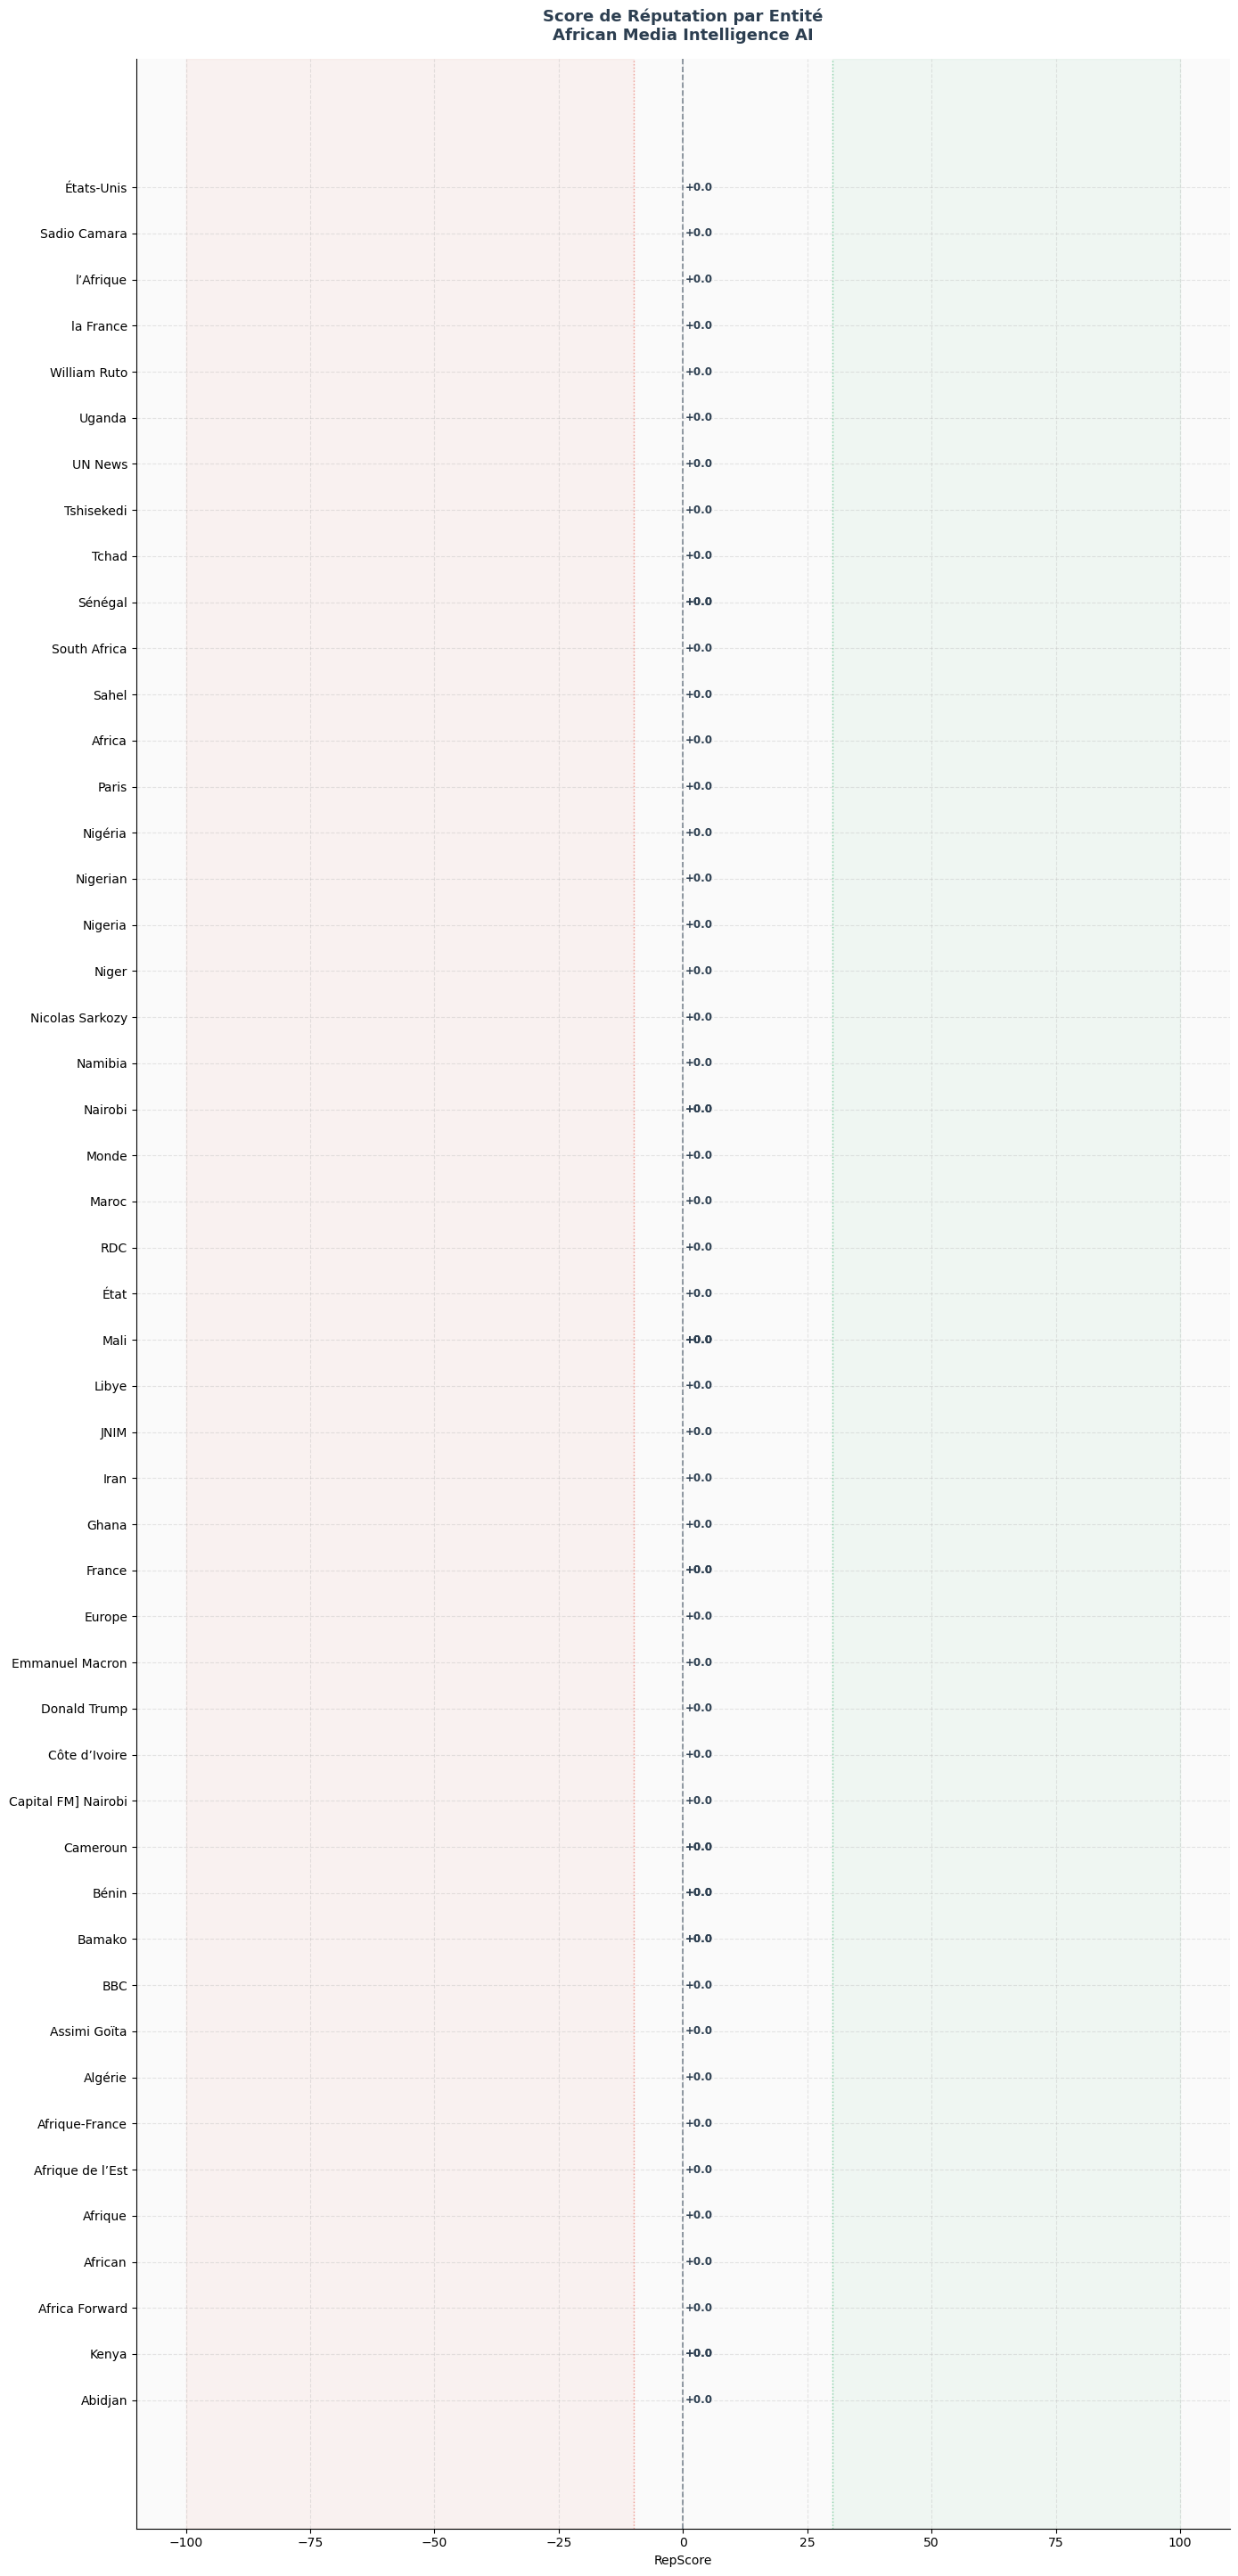

In [8]:
"""Graphique autonome RepScore avec couleurs par type d'entité."""

if df_rep is not None:
    ent_col   = next((c for c in df_rep.columns if c in ['Entité','entite']), None)
    score_col = next((c for c in df_rep.columns if c in ['RepScore','rep_score']), None)
    type_col  = next((c for c in df_rep.columns if c in ['Type','type_entite']), None)

    if ent_col and score_col:
        rep_sorted = df_rep[[ent_col, score_col] + ([type_col] if type_col else [])]\
                     .sort_values(score_col, ascending=True)

        type_colors = {'ORG': '#2980B9', 'GPE': '#27AE60',
                       'PER': '#8E44AD', 'LOC': '#E67E22'}

        colors_rep = [
            type_colors.get(row.get(type_col, 'ORG'), '#95A5A6') if type_col else '#2980B9'
            for _, row in rep_sorted.iterrows()
        ]

        fig2, ax = plt.subplots(figsize=(14, max(6, len(rep_sorted) * 0.5)),
                                facecolor='white')
        ax.set_facecolor('#FAFAFA')

        bars = ax.barh(
            rep_sorted[ent_col].values,
            rep_sorted[score_col].values,
            color=colors_rep, edgecolor='white', linewidth=0.6, height=0.7
        )

        # Valeurs
        for bar, val in zip(bars, rep_sorted[score_col].values):
            offset = 0.5 if val >= 0 else -0.5
            ha     = 'left' if val >= 0 else 'right'
            ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                    f'{val:+.1f}', va='center', ha=ha,
                    fontsize=8.5, fontweight='bold', color='#2C3E50')

        ax.axvline(x=0,   color='#2C3E50', lw=1.2, ls='--', alpha=0.6)
        ax.axvline(x=30,  color=PALETTE['positif'], lw=1, ls=':', alpha=0.5)
        ax.axvline(x=-10, color=PALETTE['negatif'],  lw=1, ls=':', alpha=0.5)
        ax.axvspan(-100, -10, alpha=0.05, color=PALETTE['negatif'])
        ax.axvspan(30,   100, alpha=0.05, color=PALETTE['positif'])

        ax.set_xlabel('RepScore', fontsize=10)
        ax.set_title('Score de Réputation par Entité\nAfrican Media Intelligence AI',
                     fontsize=13, fontweight='bold', color='#2C3E50', pad=15)

        # Légende types
        if type_col:
            legend_type = [mpatches.Patch(color=c, label=t)
                           for t, c in type_colors.items()]
            ax.legend(handles=legend_type, title='Type entité',
                      fontsize=9, title_fontsize=9,
                      loc='lower right', frameon=True)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()

        out2 = EXPORTS_DIR / f'repscore_detail_{datetime.now().strftime("%Y%m%d_%H%M")}.png'
        plt.savefig(out2, dpi=180, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        print(f'✅ Graphique RepScore détaillé : {out2}')
        plt.show()

## 5. Graphique Individuel — Évolution Sentiment HD

✅ Évolution sentiment HD : C:\Users\E682\Desktop\exports\sentiment_evolution_hd_20260512_2051.png


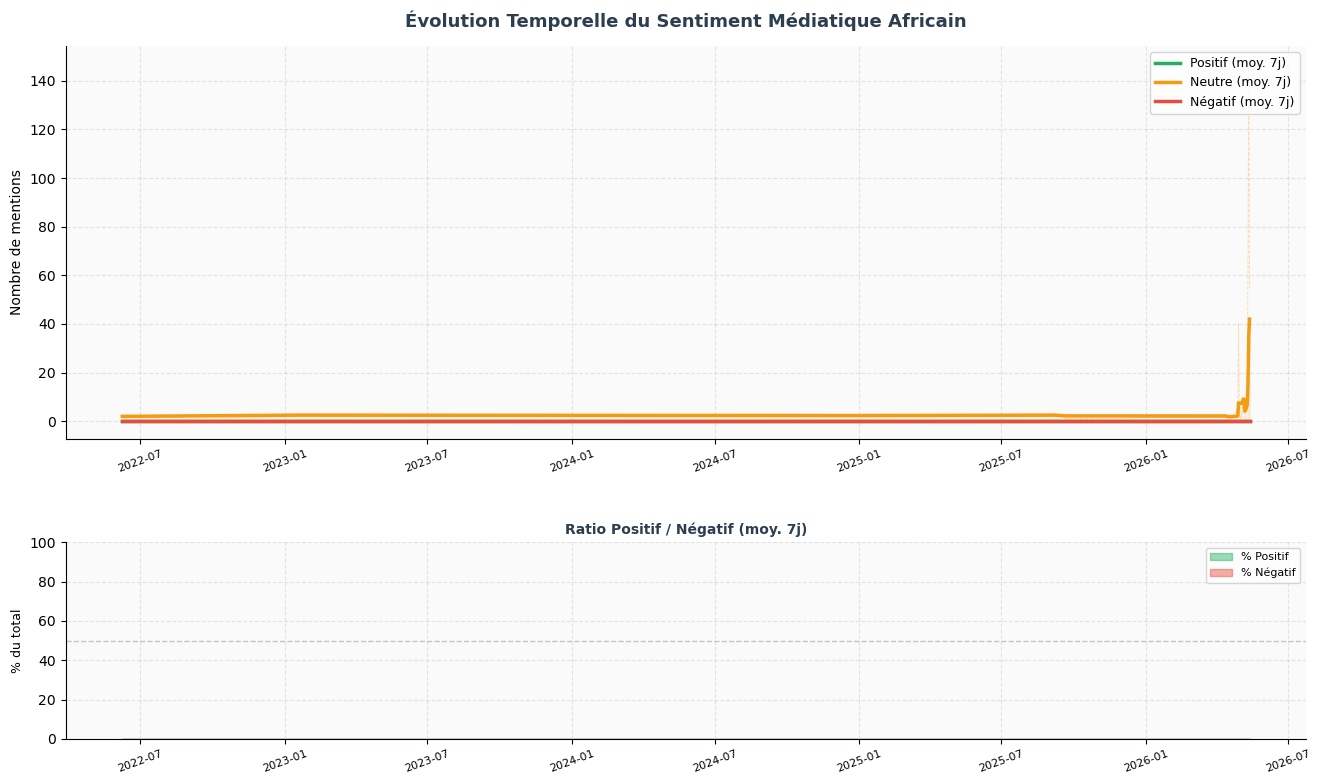

In [9]:
"""Courbes HD de l'évolution temporelle du sentiment."""

if df_evo is not None:
    date_col = next((c for c in df_evo.columns if 'date' in c.lower()), df_evo.columns[0])
    df_evo[date_col] = pd.to_datetime(df_evo[date_col], errors='coerce')
    df_evo_s = df_evo.sort_values(date_col).set_index(date_col)
    df_smooth = df_evo_s.rolling(window=7, min_periods=1).mean()

    fig3, axes = plt.subplots(2, 1, figsize=(16, 9), facecolor='white',
                               gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35})

    # ── Courbes lissées ──────────────────────────────────────────
    ax1 = axes[0]
    ax1.set_facecolor('#FAFAFA')

    config_lines = [
        ('Positif', PALETTE['positif'], '●'),
        ('Neutre',  PALETTE['neutre'],  '■'),
        ('Négatif', PALETTE['negatif'], '▲'),
    ]
    for col, color, marker in config_lines:
        if col in df_smooth.columns:
            ax1.plot(df_smooth.index, df_smooth[col],
                     color=color, linewidth=2.5,
                     label=f'{col} (moy. 7j)', zorder=3)
            ax1.fill_between(df_smooth.index, df_smooth[col],
                             alpha=0.13, color=color, zorder=2)
            # Données brutes en pointillé clair
            if col in df_evo_s.columns:
                ax1.plot(df_evo_s.index, df_evo_s[col],
                         color=color, linewidth=0.7, alpha=0.3,
                         linestyle='--', zorder=1)

    ax1.set_title('Évolution Temporelle du Sentiment Médiatique Africain',
                  fontsize=13, fontweight='bold', color='#2C3E50', pad=14)
    ax1.set_ylabel('Nombre de mentions', fontsize=10)
    ax1.legend(fontsize=9, loc='upper right', frameon=True)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.tick_params(axis='x', rotation=20, labelsize=8)

    # ── Ratio positif/négatif ────────────────────────────────────
    ax2 = axes[1]
    ax2.set_facecolor('#FAFAFA')

    if 'Positif' in df_evo_s.columns and 'Négatif' in df_evo_s.columns:
        total = df_evo_s.sum(axis=1).replace(0, np.nan)
        ratio_pos = (df_evo_s['Positif'] / total * 100).rolling(7, min_periods=1).mean()
        ratio_neg = (df_evo_s['Négatif'] / total * 100).rolling(7, min_periods=1).mean()

        ax2.fill_between(ratio_pos.index, ratio_pos,
                         alpha=0.45, color=PALETTE['positif'],
                         label='% Positif')
        ax2.fill_between(ratio_neg.index, ratio_neg,
                         alpha=0.45, color=PALETTE['negatif'],
                         label='% Négatif')
        ax2.axhline(y=50, color='#95A5A6', lw=1, ls='--', alpha=0.6)
        ax2.set_ylabel('% du total', fontsize=9)
        ax2.set_title('Ratio Positif / Négatif (moy. 7j)', fontsize=10,
                      fontweight='bold', color='#2C3E50')
        ax2.legend(fontsize=8, loc='upper right', frameon=True)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.tick_params(axis='x', rotation=20, labelsize=8)
        ax2.set_ylim(0, 100)

    plt.tight_layout()
    out3 = EXPORTS_DIR / f'sentiment_evolution_hd_{datetime.now().strftime("%Y%m%d_%H%M")}.png'
    plt.savefig(out3, dpi=180, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'✅ Évolution sentiment HD : {out3}')
    plt.show()

---

## ✅ Phase 6 Terminée

**3 fichiers image exportés dans `exports/` :**
- `dashboard_african_media_YYYYMMDD_HHMM.png` — Dashboard complet (8 visuels)
- `repscore_detail_YYYYMMDD_HHMM.png` — RepScore détaillé par entité
- `sentiment_evolution_hd_YYYYMMDD_HHMM.png` — Évolution + ratio HD

**Prochaines actions :**
- 📤 Publier les visuels sur LinkedIn (posts portfolio)
- 📁 Pusher le repo complet sur GitHub
- 🎯 Générer une présentation Gamma du projet
